### Multi-Linear Regression - Example and Practice Exercise

#### Exercise: Multiple Linear Regression

Problem Statement

A real estate company in India wants to predict the selling price of houses based on their characteristics. They have collected data for houses including:

* area (in square feet)
* bedrooms (number of bedrooms)
* age (age of the house in years)
* price (in lakhs INR)

The goal is to build a Multiple Linear Regression model to predict house prices.
car_prices.csv
CSV

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

In [4]:
df = pd.read_csv('car_prices.csv')
df

,age,engine_capacity,mileage,price
0,5,1200,15.5,4.5
1,3,1500,16.2,6.2
2,4,1300,14.8,5.4
3,6,1600,13.5,6.9
4,2,1400,17.1,5.8
...,...,...,...,...
59,5,1600,13.4,6.0
60,6,1500,13.2,6.3
61,2,1250,17.2,4.3
62,4,1350,15.1,5.2


In [5]:
df.shape

(64, 4)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              64 non-null     int64  
 1   engine_capacity  64 non-null     int64  
 2   mileage          64 non-null     float64
 3   price            64 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 2.1 KB


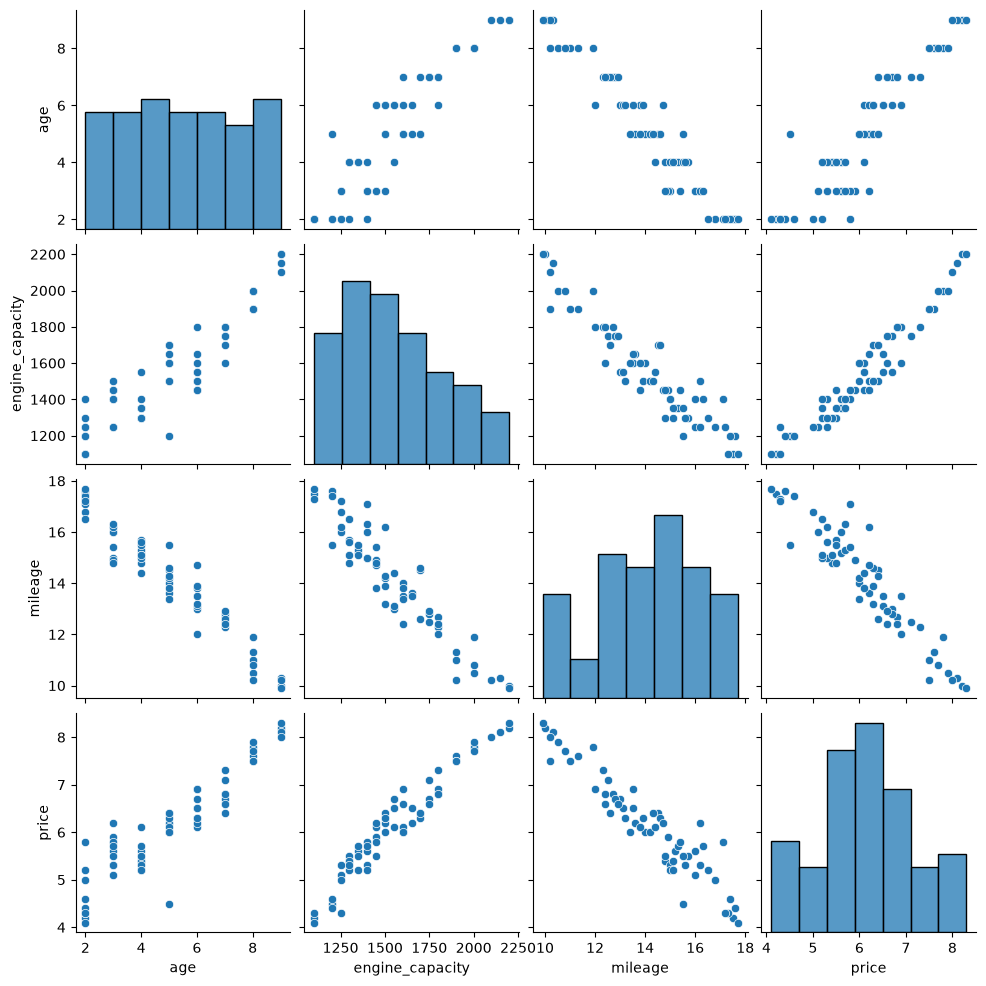

In [7]:
sns.pairplot(df)
plt.show()

In [8]:
df.isnull().sum()

age                0
engine_capacity    0
mileage            0
price              0
dtype: int64

In [9]:
X = df[['age', 'engine_capacity', 'mileage']]
y = df['price']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining records:", len(X_train))
print("Testing records:", len(X_test))



Training records: 51
Testing records: 13


In [11]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.11, 0. ,-0.05]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['age','engine_capacity','mileage']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.655
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [12]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

print("R-squared:", r2)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

R-squared: 0.8589796730925179
Mean Absolute Error: 0.27918546672492306
Mean Squared Error: 0.12580014487912433
Root Mean Squared Error: 0.35468316125681004


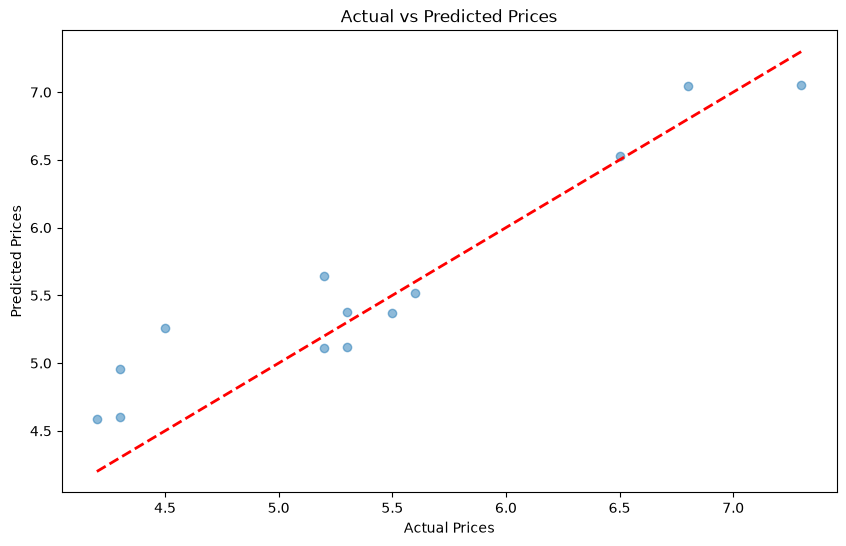

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

## Multiple Linear Regression for House Price Prediction


In [14]:
df = pd.read_csv('house_prices_mlr.csv')
df  

,area,bedrooms,age,price
0,850,2,5,46.2
1,900,2,4,42.1
2,1000,3,6,55.8
3,1200,3,8,62.9
4,1500,4,10,76.3
...,...,...,...,...
65,780,2,5,40.2
66,1150,3,8,62.7
67,1450,4,12,76.6
68,1750,4,16,93.5


In [15]:
df.head()

,area,bedrooms,age,price
0,850,2,5,46.2
1,900,2,4,42.1
2,1000,3,6,55.8
3,1200,3,8,62.9
4,1500,4,10,76.3


In [16]:
df.describe()

,area,bedrooms,age,price
count,70.000000,70.000000,70.000000,70.000000
mean,1306.714286,3.214286,10.142857,68.285714
std,426.416553,1.101946,4.511774,23.010768
min,700.000000,1.000000,4.000000,32.400000
25%,980.000000,2.000000,6.000000,49.650000
50%,1250.000000,3.000000,9.000000,65.800000
75%,1600.000000,4.000000,13.000000,82.975000
max,2400.000000,5.000000,22.000000,127.800000


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   area      70 non-null     int64  
 1   bedrooms  70 non-null     int64  
 2   age       70 non-null     int64  
 3   price     70 non-null     float64
dtypes: float64(1), int64(3)
memory usage: 2.3 KB


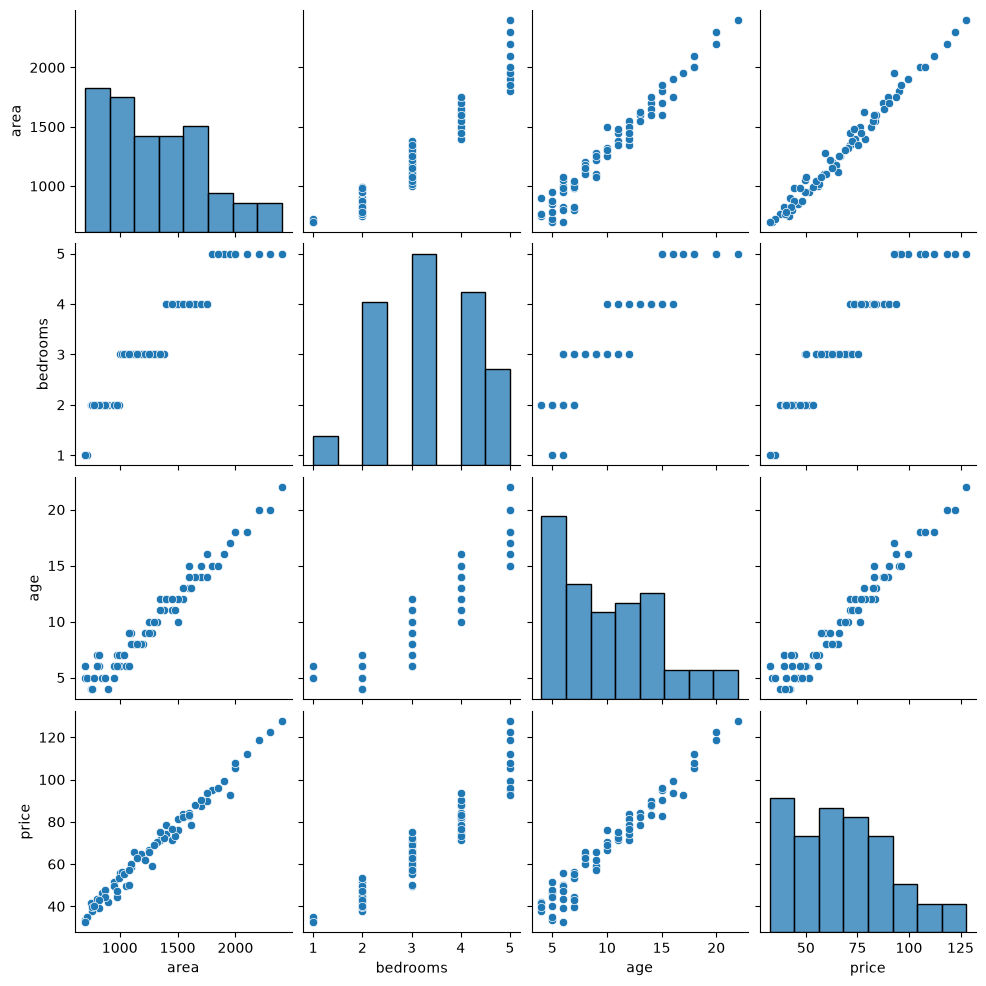

In [18]:
df.isnull().sum()
sns.pairplot(df)
plt.show()

In [19]:
X = df[["area", "bedrooms", "age"]]
y = df["price"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [21]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R-squared:", r2)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

R-squared: 0.9590118006581043
Mean Absolute Error: 3.4234547109301654
Mean Squared Error: 20.444905466798936
Root Mean Squared Error: 4.521604302324445


In [27]:
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>